# Milestone 1: Exploratory Data Analysis
## Predicting Potentially Hazardous Asteroids (NASA JPL Asteroid Dataset)

Team 1 | Members: Samuel T, Ishita C, Sebastian A | CAI 4105 Machine Learning, Fall 2026

Data: `dataset.csv` from the Kaggle "Asteroid Dataset" (sakhawat18), stored in the repo as `dataset.zip` and extracted automatically by the load cell. Every figure is saved to `figures/` and used in Section 3 of the report.

In [1]:
# Standard libraries and plotting
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

# Show all columns and use a wide display so tables are not cut off
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

DATA_PATH = "dataset.csv"   # change this if your file has a different name or folder
FIG_DIR = "figures"         # every plot is saved here as a PNG for the report
RANDOM_STATE = 42           # fixed seed so samples and splits are reproducible
os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(name):
    """Tidy the layout, save the current figure as a PNG, and show it."""
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches="tight")
    plt.show()

## 1. Load the data

In [2]:
# low_memory=False stops pandas from guessing column types in chunks, which avoids mixed-type warnings
# The repo stores the data as dataset.zip (Git LFS); extract it on first run
import zipfile
if not os.path.exists(DATA_PATH) and os.path.exists("dataset.zip"):
    with zipfile.ZipFile("dataset.zip") as z:
        z.extractall(".")

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape (rows, columns):", df.shape)
display(df.head())

Shape (rows, columns): (958524, 45)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,albedo,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,58600,20190427.0,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,59000,20200531.0,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,59000,20200531.0,J2000,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,2.018112e+07,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,58600,20190427.0,J2000,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,2.018051e+07,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,59000,20200531.0,J2000,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,2.020032e+07,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


## 2. Column types and data dictionary check

Report location: Section 3.1 (size, numeric versus text columns) and Section 3.3 (key variables table).

In [3]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
text_cols = [c for c in df.columns if c not in numeric_cols]
print(len(numeric_cols), "numeric columns and", len(text_cols), "text columns")
print("Text columns:", text_cols)

# One row per column: type, how many values exist, how many are missing, how many distinct values
dictionary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.iloc[0].astype(str),
})
display(dictionary)

35 numeric columns and 10 text columns
Text columns: ['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id', 'equinox', 'class']


,dtype,non_null,missing_pct,n_unique,example_value
id,str,958524,0.00,958524,a0000001
spkid,int64,958524,0.00,958524,2000001
full_name,str,958524,0.00,958524,1 Ceres
pdes,str,958524,0.00,958524,1
name,str,22064,97.70,22064,Ceres
prefix,str,18,100.00,1,NaN
neo,str,958520,0.00,2,N
pha,str,938603,2.08,2,N
H,float64,952261,0.65,9489,3.4
diameter,float64,136209,85.79,16591,939.4


## 3. Target variable: `pha`

Report location: Section 3.1 (class balance) and Section 3.4 (target distribution row).

,count,percent
N (not hazardous),936537,97.706
Y (hazardous),2066,0.216
missing,19921,2.078


Labeled rows: 938603
Hazardous share of labeled rows (%): 0.22
About 1 hazardous object per 454 labeled objects
Accuracy of a model that always predicts N (%): 99.78


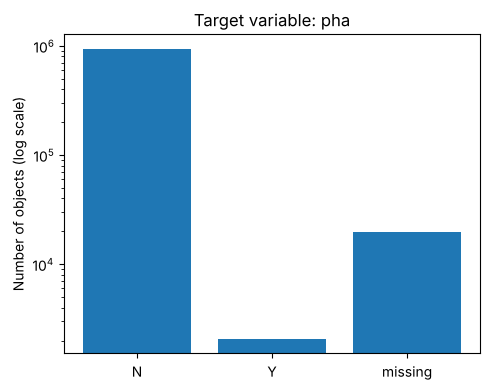

In [4]:
n_n = int((df["pha"] == "N").sum())
n_y = int((df["pha"] == "Y").sum())
n_missing = int(df["pha"].isna().sum())

target_table = pd.DataFrame(
    {"count": [n_n, n_y, n_missing]},
    index=["N (not hazardous)", "Y (hazardous)", "missing"],
)
target_table["percent"] = (target_table["count"] / len(df) * 100).round(3)
display(target_table)

# Only rows with a label can be used for supervised learning
labeled = df[df["pha"].notna()].copy()
labeled["y"] = (labeled["pha"] == "Y").astype(int)   # 1 = hazardous, 0 = not hazardous
print("Labeled rows:", len(labeled))
print("Hazardous share of labeled rows (%):", round(labeled["y"].mean() * 100, 3))
print("About 1 hazardous object per", round(len(labeled) / n_y), "labeled objects")
print("Accuracy of a model that always predicts N (%):", round((1 - labeled["y"].mean()) * 100, 2))

# Bar chart on a log scale so the small Y bar is still visible
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["N", "Y", "missing"], [n_n, n_y, n_missing])
ax.set_yscale("log")
ax.set_ylabel("Number of objects (log scale)")
ax.set_title("Target variable: pha")
save_fig("target_distribution.png")

**Notes:** Only 0.22% of labeled objects are hazardous (about 1 in 454), so a model that always predicts N is 99.78% accurate while finding zero hazardous objects. Accuracy rewards ignoring the class we care about, so we compare models on recall, precision, and PR-AUC for the hazardous class instead.

## 4. Missing values

Report location: Section 3.4 (missing values row) and Section 3.5 (data quality).

,missing_percent
prefix,100.00
name,97.70
albedo,85.91
diameter_sigma,85.80
diameter,85.79
sigma_per,2.08
sigma_ad,2.08
sigma_om,2.08
sigma_ma,2.08
sigma_q,2.08


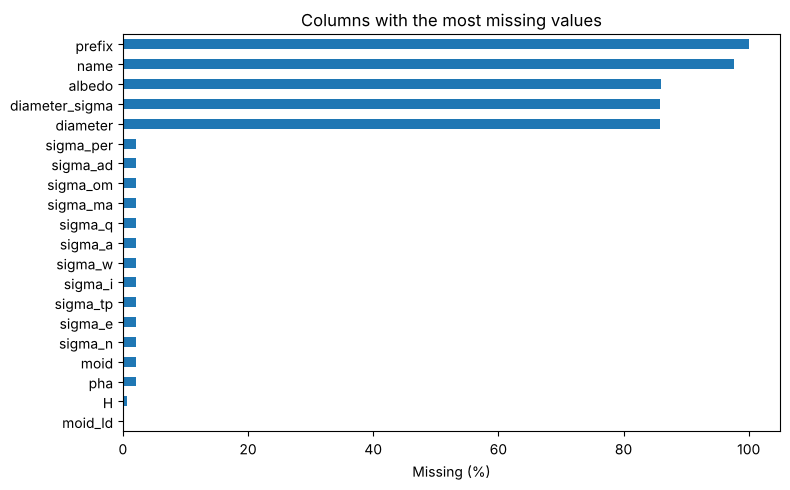

pha missing: 19921
moid missing: 19921
Rows missing BOTH pha and moid: 19921
Unlabeled rows that have no value in any sigma column: 19921


In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0].round(2).to_frame("missing_percent"))

# Bar chart of the 20 columns with the most missing values
top_missing = missing_pct[missing_pct > 0].head(20)
fig, ax = plt.subplots(figsize=(8, 5))
top_missing[::-1].plot(kind="barh", ax=ax)
ax.set_xlabel("Missing (%)")
ax.set_title("Columns with the most missing values")
save_fig("missing_values.png")

# Do the unlabeled rows overlap with the rows that lack moid and the sigma (uncertainty) columns?
sigma_cols = [c for c in df.columns if c.startswith("sigma_")]
unlabeled = df["pha"].isna()
print("pha missing:", int(unlabeled.sum()))
print("moid missing:", int(df["moid"].isna().sum()))
print("Rows missing BOTH pha and moid:", int((unlabeled & df["moid"].isna()).sum()))
print("Unlabeled rows that have no value in any sigma column:", int(df.loc[unlabeled, sigma_cols].isna().all(axis=1).sum()))

## 5. Summary statistics and distributions

Report location: Section 3.4 (summary statistics and distributions rows).

In [6]:
display(df[numeric_cols].describe().T)

# Skewness: values far from 0 mean a long tail on one side (a candidate for a log transform)
skew = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print("Most skewed numeric columns:")
display(skew.head(10).round(2).to_frame("skewness"))

,count,mean,std,min,25%,50%,75%,max
spkid,958524.0,3.810114e+06,6.831541e+06,2.000001e+06,2.239632e+06,2.479262e+06,3.752518e+06,5.401723e+07
H,952261.0,1.690641e+01,1.790405e+00,-1.100000e+00,1.610000e+01,1.690000e+01,1.771400e+01,3.320000e+01
diameter,136209.0,5.506429e+00,9.425164e+00,2.500000e-03,2.780000e+00,3.972000e+00,5.765000e+00,9.394000e+02
albedo,135103.0,1.306272e-01,1.103228e-01,1.000000e-03,5.300000e-02,7.900000e-02,1.900000e-01,1.000000e+00
diameter_sigma,136081.0,4.791844e-01,7.828952e-01,5.000000e-04,1.800000e-01,3.320000e-01,6.200000e-01,1.400000e+02
epoch,958524.0,2.458869e+06,7.016716e+02,2.425052e+06,2.459000e+06,2.459000e+06,2.459000e+06,2.459000e+06
epoch_mjd,958524.0,5.886878e+04,7.016716e+02,2.505100e+04,5.900000e+04,5.900000e+04,5.900000e+04,5.900000e+04
epoch_cal,958524.0,2.019693e+07,1.930354e+04,1.927062e+07,2.020053e+07,2.020053e+07,2.020053e+07,2.020053e+07
e,958524.0,1.561163e-01,9.264264e-02,0.000000e+00,9.219296e-02,1.450017e-01,2.006503e-01,1.855356e+00
a,958524.0,2.902143e+00,3.971950e+01,-1.470245e+04,2.387835e+00,2.646969e+00,3.001932e+00,3.348890e+04


Most skewed numeric columns:


,skewness
rms,976.74
sigma_tp,960.97
sigma_ma,959.73
sigma_w,959.73
per_y,953.01
per,953.00
ad,864.42
sigma_om,793.99
sigma_ad,660.97
sigma_a,627.86


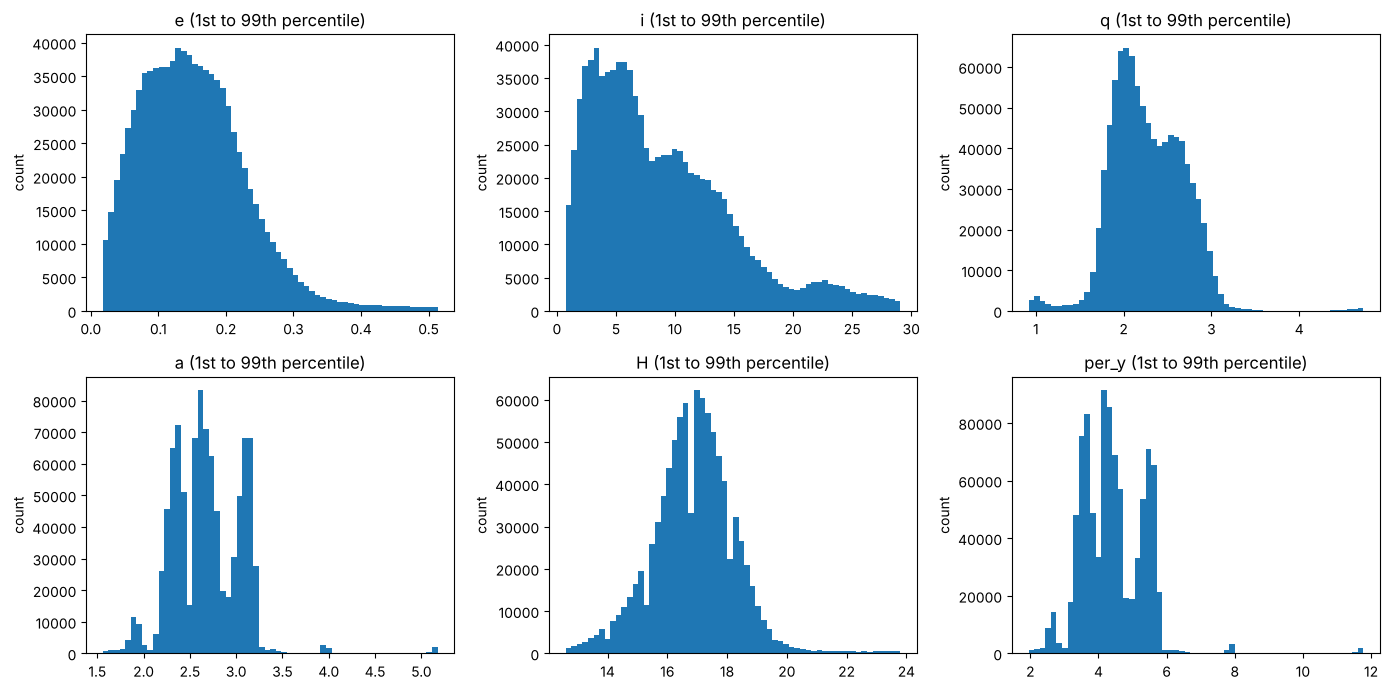

In [7]:
# Histograms of key variables. Extreme values would squash the plot, so each panel
# shows only the 1st to 99th percentile (the table above still reports the full range).
dist_cols = ["e", "i", "q", "a", "H", "per_y"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), dist_cols):
    s = df[col].dropna()
    lo, hi = s.quantile([0.01, 0.99])
    ax.hist(s[(s >= lo) & (s <= hi)], bins=60)
    ax.set_title(f"{col} (1st to 99th percentile)")
    ax.set_ylabel("count")
save_fig("distributions.png")

,count
class,
MBA,855954
OMB,28355
IMB,20360
MCA,18685
APO,12687
AMO,8457
TJN,8221
TNO,3468
ATE,1729


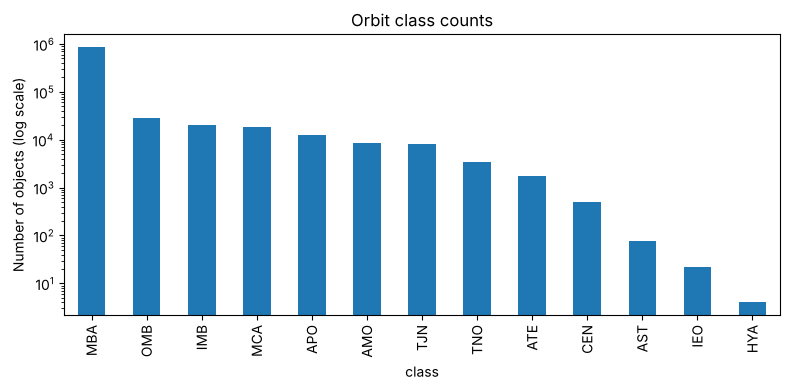

In [8]:
# Orbit classes (log scale because the main belt dominates)
class_counts = df["class"].value_counts()
display(class_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind="bar", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Number of objects (log scale)")
ax.set_title("Orbit class counts")
save_fig("orbit_classes.png")

**Notes:** `e` and `i` are right-skewed with long upper tails, and `a` sits in a narrow band between about 2 and 3.5 AU, the signature of the main belt. MBA alone holds 855,954 objects (89.3%). Hazardous objects come from the much smaller near-Earth population, so most of the data is easy negatives that tell the model little about the boundary.

## 6. Features by hazard class

Report location: Section 3.4 (features by class row).

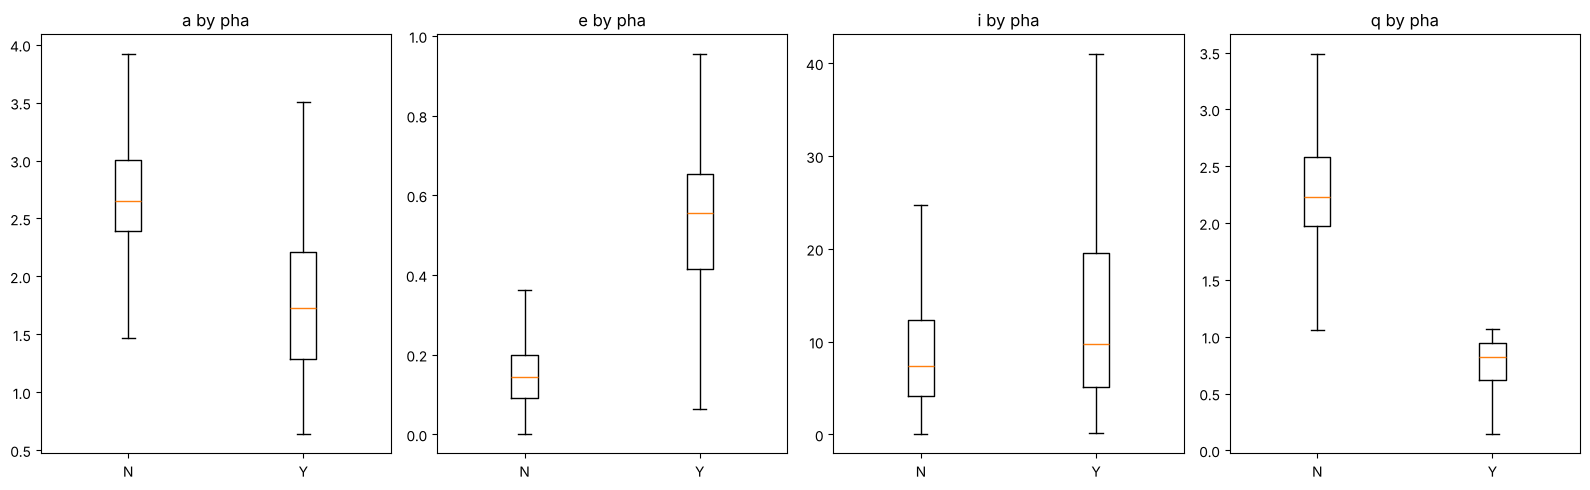

Median by class (medians resist the extreme values):


,a,e,i,q
pha,,,,
N,2.648,0.145,7.401,2.228
Y,1.731,0.557,9.763,0.817


Mean by class:


,a,e,i,q
pha,,,,
N,2.909,0.155,9.038,2.401
Y,1.773,0.533,13.818,0.760


pha,N,Y,percent_Y
class,,,
AMO,8338,118,1.395
APO,10919,1768,13.936
AST,75,0,0.000
ATE,1555,174,10.064
CEN,504,0,0.000
HYA,4,0,0.000
IEO,16,6,27.273
IMB,19903,0,0.000
MBA,837430,0,0.000


In [9]:
box_cols = ["a", "e", "i", "q"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, box_cols):
    groups = [labeled.loc[labeled["pha"] == g, col].dropna() for g in ["N", "Y"]]
    ax.boxplot(groups, showfliers=False)   # outliers hidden so the boxes stay readable
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["N", "Y"])
    ax.set_title(f"{col} by pha")
save_fig("features_by_class.png")

print("Median by class (medians resist the extreme values):")
display(labeled.groupby("pha")[box_cols].median().round(3))
print("Mean by class:")
display(labeled.groupby("pha")[box_cols].mean().round(3))

# Which orbit classes contain hazardous objects?
hazard_by_class = pd.crosstab(labeled["class"], labeled["pha"])
hazard_by_class["percent_Y"] = (hazard_by_class["Y"] / (hazard_by_class["N"] + hazard_by_class["Y"]) * 100).round(3)
display(hazard_by_class)

In [10]:
# Hazardous objects are a subset of near-Earth objects (neo = Y)
display(pd.crosstab(labeled["neo"], labeled["pha"], margins=True))
neo_labeled = labeled[labeled["neo"] == "Y"]
print("Labeled NEOs:", len(neo_labeled))
print("Hazardous share within NEOs (%):", round(neo_labeled["y"].mean() * 100, 2))

pha,N,Y,All
neo,,,
N,915705,0,915705
Y,20828,2066,22894
All,936533,2066,938599


Labeled NEOs: 22894
Hazardous share within NEOs (%): 9.02


**Notes:** Hazardous objects have a much smaller perihelion distance (median `q` 0.82 vs 2.23 AU), much higher eccentricity (median `e` 0.56 vs 0.15), smaller `a` (1.73 vs 2.65 AU) and somewhat higher inclination (9.8 vs 7.4 degrees). This matches orbital reasoning: an eccentric orbit with perihelion inside about 1 AU is what lets an object reach Earth's orbit. Every PHA belongs to one of four near-Earth classes (APO, ATE, AMO, IEO).

## 7. How the label is defined (leakage check)

NASA defines a hazardous asteroid as one with moid <= 0.05 AU and H <= 22. This cell tests how well that rule explains `pha` in this file.

Report location: Section 3.4 (label dependence row) and Section 2.1.

In [11]:
moid_ok = (labeled["moid"] <= 0.05).rename("moid<=0.05")
h_ok = (labeled["H"] <= 22).rename("H<=22")   # a missing H counts as False here
display(pd.crosstab(labeled["pha"], [moid_ok, h_ok]))

# Rows where the label disagrees with the rule
rule = moid_ok & h_ok
exceptions = labeled[(labeled["pha"] == "Y") != rule]
print("Exceptions (label disagrees with the rule):", len(exceptions))
print("Share of labeled rows (%):", round(len(exceptions) / len(labeled) * 100, 4))
print("Exceptions where H is missing:", int(exceptions["H"].isna().sum()))
display(exceptions[["full_name", "pha", "H", "moid", "diameter", "class"]].sort_values(["pha", "H"]))

moid<=0.05  False         True       
H<=22       False   True  False True 
pha                                  
N           11248  916231  9021    37
Y               0       0    19  2047

Exceptions (label disagrees with the rule): 56
Share of labeled rows (%): 0.006
Exceptions where H is missing: 0


,full_name,pha,H,moid,diameter,class
722158,(2012 KN11),N,21.9,0.021007,NaN,APO
828371,(2015 FC35),N,21.9,0.021271,NaN,APO
848189,(2015 RE36),N,21.9,0.000493,NaN,APO
866784,(2015 XA352),N,21.9,0.044215,NaN,AMO
871267,(2016 AF193),N,21.9,0.010271,NaN,ATE
513311,513312 (2007 DM41),N,22.0,0.007597,NaN,APO
600147,(2006 KQ1),N,22.0,0.048944,NaN,AMO
601749,(2006 QJ65),N,22.0,0.046971,NaN,APO
626524,(2007 VK184),N,22.0,0.000500,NaN,APO
635260,(2008 GC110),N,22.0,0.042826,NaN,APO


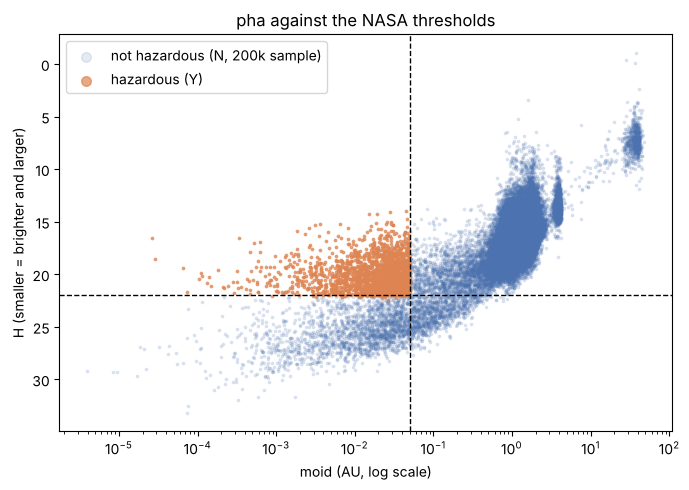

H range of the 56 exceptions: 21.9 to 22.4


In [12]:
# Picture of the rule: hazardous objects sit exactly in the moid <= 0.05, H <= 22 corner
plot_df = labeled.dropna(subset=["moid", "H"])
plot_df = pd.concat([plot_df[plot_df["y"] == 1],
                     plot_df[plot_df["y"] == 0].sample(200_000, random_state=RANDOM_STATE)])
fig, ax = plt.subplots(figsize=(7, 5))
for label, color, alpha in [(0, "#4C72B0", 0.15), (1, "#DD8452", 0.7)]:
    part = plot_df[plot_df["y"] == label]
    ax.scatter(part["moid"].clip(lower=1e-6), part["H"], s=3, alpha=alpha, color=color,
               label="hazardous (Y)" if label else "not hazardous (N, 200k sample)")
ax.axvline(0.05, ls="--", c="k", lw=1)
ax.axhline(22, ls="--", c="k", lw=1)
ax.set_xscale("log")
ax.invert_yaxis()   # brighter (larger) objects at the top
ax.set_xlabel("moid (AU, log scale)")
ax.set_ylabel("H (smaller = brighter and larger)")
ax.set_title("pha against the NASA thresholds")
ax.legend(markerscale=4)
save_fig("moid_vs_H.png")

print("H range of the 56 exceptions:", exceptions["H"].min(), "to", exceptions["H"].max())

## 8. Data quality checks

Report location: Section 3.5.

In [13]:
print("Duplicate id values:", int(df["id"].duplicated().sum()))
print("Duplicate full_name values:", int(df["full_name"].duplicated().sum()))
print("Fully duplicated rows:", int(df.duplicated().sum()))

# Values that need a decision (hyperbolic orbits are valid objects, not errors)
print("\nOrbit checks:")
print("e >= 1 (hyperbolic, unbound orbit):", int((df["e"] >= 1).sum()))
print("a < 0 (same cause as e > 1):", int((df["a"] < 0).sum()))
print("ma outside 0 to 360 degrees:", int(((df["ma"] < 0) | (df["ma"] > 360)).sum()))
print("i outside 0 to 180 degrees:", int(((df["i"] < 0) | (df["i"] > 180)).sum()))
print("rms greater than 10 (very poor orbit fit):", int((df["rms"] > 10).sum()))

# The sigma (uncertainty) columns: how often are they exactly zero?
print("\nShare of rows where each sigma column equals 0:")
display((df[sigma_cols] == 0).mean().round(3).to_frame("share_equal_zero"))

# Near-constant columns carry almost no information for a model
print("Near-constant columns:")
for col in ["epoch", "epoch_mjd", "epoch_cal", "equinox"]:
    top_share = df[col].value_counts(normalize=True).iloc[0]
    print(f"  {col}: {df[col].nunique()} distinct values, the most common covers {top_share * 100:.1f}% of rows")

Duplicate id values: 0


Duplicate full_name values: 0


Fully duplicated rows: 0

Orbit checks:
e >= 1 (hyperbolic, unbound orbit): 4
a < 0 (same cause as e > 1): 4
ma outside 0 to 360 degrees: 95
i outside 0 to 180 degrees: 0
rms greater than 10 (very poor orbit fit): 3

Share of rows where each sigma column equals 0:


,share_equal_zero
sigma_e,0.0
sigma_a,0.0
sigma_q,0.0
sigma_i,0.0
sigma_om,0.0
sigma_w,0.0
sigma_ma,0.0
sigma_ad,0.0
sigma_n,0.0
sigma_tp,0.0


Near-constant columns:
  epoch: 5246 distinct values, the most common covers 94.9% of rows
  epoch_mjd: 5246 distinct values, the most common covers 94.9% of rows
  epoch_cal: 5246 distinct values, the most common covers 94.9% of rows
  equinox: 1 distinct values, the most common covers 100.0% of rows


## 9. Correlation analysis

Report location: Section 3.4 (correlation row) and Section 3.5 (redundant columns).

Pearson correlation is easily dominated by a few extreme values, so we also compute Spearman (rank) correlation on a random sample of 100,000 rows.

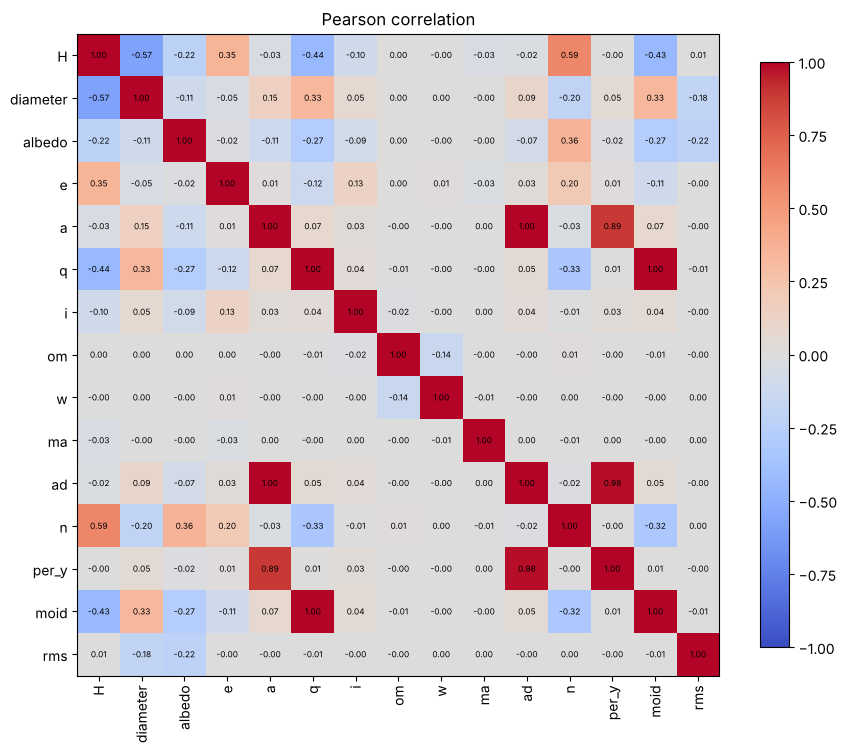

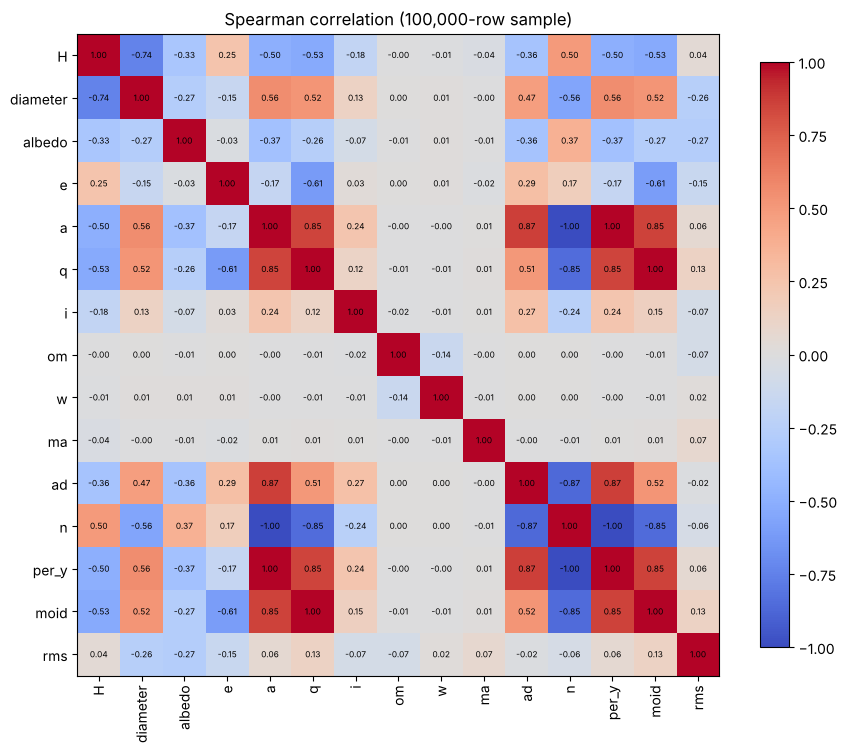

Column pairs with |Pearson| > 0.9 (all numeric columns):


,,abs_correlation
per,per_y,1.000
epoch,epoch_mjd,1.000
moid,moid_ld,1.000
sigma_w,sigma_ma,1.000
sigma_ma,sigma_tp,1.000
sigma_w,sigma_tp,1.000
q,moid,1.000
epoch,epoch_cal,1.000
epoch_mjd,epoch_cal,1.000
a,ad,1.000


Correlation with the target:


,pearson,spearman
q,-0.036,-0.080
moid,-0.030,-0.080
e,0.190,0.075
H,0.083,0.070
a,-0.001,-0.064
n,0.171,0.064
diameter,-0.020,-0.064
per_y,-0.000,-0.064
rms,-0.001,-0.039
i,0.034,0.017


In [14]:
def heatmap(c, title, name):
    """Draw a labeled correlation heatmap and save it."""
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(c.values, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(c)))
    ax.set_xticklabels(c.columns, rotation=90)
    ax.set_yticks(range(len(c)))
    ax.set_yticklabels(c.index)
    for r in range(len(c)):
        for k in range(len(c)):
            ax.text(k, r, f"{c.iloc[r, k]:.2f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    save_fig(name)


def top_pairs(c, threshold=0.9):
    """List each pair of columns once (upper triangle) with absolute correlation above the threshold."""
    upper = c.abs().where(np.triu(np.ones(c.shape, dtype=bool), k=1))
    pairs = upper.stack()
    return pairs[pairs > threshold].sort_values(ascending=False).round(3)


corr_cols = ["H", "diameter", "albedo", "e", "a", "q", "i", "om", "w", "ma", "ad", "n", "per_y", "moid", "rms"]

pearson = df[corr_cols].corr()
spearman = df[corr_cols].sample(min(100_000, len(df)), random_state=RANDOM_STATE).corr(method="spearman")

heatmap(pearson, "Pearson correlation", "corr_pearson.png")
heatmap(spearman, "Spearman correlation (100,000-row sample)", "corr_spearman.png")

print("Column pairs with |Pearson| > 0.9 (all numeric columns):")
display(top_pairs(df[numeric_cols].corr()).to_frame("abs_correlation"))

# Correlation of each variable with the target (1 = hazardous). H and moid are expected to rank high.
target_corr = pd.DataFrame({
    "pearson": labeled[corr_cols].corrwith(labeled["y"]),
    "spearman": labeled[corr_cols].corrwith(labeled["y"], method="spearman"),
}).round(3)
print("Correlation with the target:")
display(target_corr.sort_values("spearman", key=abs, ascending=False))

Pearson correlation of q and moid: 0.99973
Median of (q - moid) in AU: 0.99


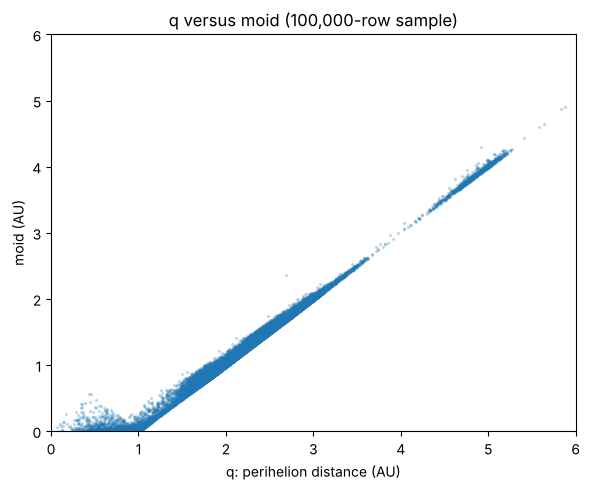

In [15]:
# Perihelion distance q versus moid: is q nearly a copy of moid?
pair = df[["q", "moid"]].dropna()
print("Pearson correlation of q and moid:", round(pair["q"].corr(pair["moid"]), 5))
print("Median of (q - moid) in AU:", round((pair["q"] - pair["moid"]).median(), 3))

sample = pair.sample(min(100_000, len(pair)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample["q"], sample["moid"], s=2, alpha=0.2)
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel("q: perihelion distance (AU)")
ax.set_ylabel("moid (AU)")
ax.set_title("q versus moid (100,000-row sample)")
save_fig("q_vs_moid.png")

**Notes:** Redundant groups: `per`/`per_y`/`n` (all functions of `a`), `a`/`ad`, `moid`/`moid_ld`, `epoch`/`epoch_mjd`/`epoch_cal`, `tp`/`tp_cal`, and several `sigma_*` columns. We keep `a`, `e`, `q`, `per_y` and one copy of each other group. `q` tracks `moid` almost exactly (Pearson 0.9997, median `q - moid` = 0.99 AU), so a model without `moid` can still recover most of its information from `q`. We will run an ablation without `q` to measure this.

## 10. Preparation preview and stratified split

This cell applies the plan from Section 4 of the report: remove identifiers, near-constant columns, label-defining columns, and heavily missing columns, drop rows with no label, and split with stratification.

Report location: Sections 4.1 and 4.4.

In [16]:
id_cols = ["id", "spkid", "full_name", "pdes", "name", "prefix", "orbit_id"]
constant_cols = ["equinox", "epoch", "epoch_mjd", "epoch_cal", "tp", "tp_cal"]
leakage_cols = ["moid", "moid_ld", "H", "diameter"]          # define or are computed from the label rule
sparse_cols = ["albedo", "diameter_sigma"]                   # more than 85% missing
drop_for_primary = id_cols + constant_cols + leakage_cols + sparse_cols + sigma_cols

X = labeled.drop(columns=drop_for_primary + ["pha", "y"])
y = labeled["y"]
print("Feature columns for the primary model:", X.columns.tolist())
print("Rows used:", len(X))

print("\nMissing values left in the features (%):")
left_missing = (X.isna().mean() * 100).round(3)
display(left_missing[left_missing > 0].to_frame("missing_pct"))

# 70 percent train, 15 percent validation, 15 percent test, stratified on the target
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

split_summary = pd.DataFrame({
    "rows": [len(y_train), len(y_val), len(y_test)],
    "hazardous": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
}, index=["train", "validation", "test"])
split_summary["hazardous_percent"] = (split_summary["hazardous"] / split_summary["rows"] * 100).round(3)
display(split_summary)

Feature columns for the primary model: ['neo', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'per_y', 'class', 'rms']
Rows used: 938603

Missing values left in the features (%):


,missing_pct


,rows,hazardous,hazardous_percent
train,657022,1446,0.22
validation,140790,310,0.22
test,140791,310,0.22


## 11. Summary of findings
- **Target and balance:** 2,066 hazardous of 938,603 labeled objects (0.22%); 19,921 rows unlabeled. Always predicting N gives 99.78% accuracy, so accuracy is not used.
- **Scope:** every PHA is a near-Earth object in class APO, ATE, AMO or IEO. Within the 22,894 labeled NEOs the hazardous share is 9.0%.
- **Missing data:** the 19,921 unlabeled rows are exactly the rows missing `moid` and every `sigma_*` value, so they are dropped. `diameter`, `albedo`, `diameter_sigma` are about 86% missing and are dropped from the primary model. `name` and `prefix` are identifiers and mostly empty.
- **Label rule and leakage:** `moid <= 0.05 and H <= 22` reproduces the label for all but 56 rows (99.994%), and all 56 have H between 21.9 and 22.4, i.e. rounding at the size threshold. The primary model therefore excludes `moid`, `moid_ld`, `H` and `diameter`. `q` is nearly a copy of `moid`, which we test with an ablation.
- **Redundant or near-constant columns:** `per`/`per_y`/`n`, `a`/`ad`, `moid`/`moid_ld`, the three epoch columns (94.9% share one epoch), `tp`/`tp_cal`; `equinox` is constant.
- **Outliers:** 4 hyperbolic orbits (e >= 1, a < 0), 95 rows with mean anomaly outside 0 to 360 degrees, 3 rows with rms above 10, and `sigma_*` columns reaching about 8.8e11. Handled with log transforms, wrapping `ma`, and robust (median) imputation.
- **What surprised us:** how completely two columns determine the label, and how weak every single feature's correlation with `pha` is (|Spearman| at most 0.08); hazard depends on a combination of orbit shape and size, not any one variable.